In [1]:
!pip install pillow tqdm nltk rouge bert_score
!pip install ipywidgets --upgrade
!pip install git+https://github.com/salaniz/pycocoevalcap.git
!jupyter nbextension enable --py widgetsnbextension --sys-prefix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 54.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import string
from PIL import Image
from pickle import dump, load

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import Xception
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import top_k_categorical_accuracy
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, LayerNormalization, Layer

from rouge import Rouge
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.spice.spice import Spice
from bert_score import score

from tqdm import tqdm
tqdm().pandas()

0it [00:00, ?it/s]


In [3]:
def load_doc(filename):
    with open(filename, 'r') as file:
        text = file.read()
    return text

def all_img_captions(filename):
    file = load_doc(filename)
    captions = file.split('\n')
    descriptions = {}
    for caption in captions[:-1]:
        img, caption = caption.split('\t')
        if img[:-2] not in descriptions:
            descriptions[img[:-2]] = [caption]
        else:
            descriptions[img[:-2]].append(caption)
    return descriptions

def cleaning_text(captions):
    table = str.maketrans('', '', string.punctuation)
    for img, caps in captions.items():
        for i, img_caption in enumerate(caps):
            img_caption = img_caption.replace("-", " ")
            desc = img_caption.split()
            desc = [word.lower() for word in desc]
            desc = [word.translate(table) for word in desc]
            desc = [word for word in desc if len(word) > 1 and word.isalpha()]
            img_caption = ' '.join(desc)
            captions[img][i] = img_caption
    return captions

def text_vocabulary(descriptions):
    vocab = set()
    for key in descriptions.keys():
        [vocab.update(d.split()) for d in descriptions[key]]
    return vocab

def save_descriptions(descriptions, filename):
    lines = list()
    for key, desc_list in descriptions.items():
        for desc in desc_list:
            lines.append(key + '\t' + desc)
    data = "\n".join(lines)
    with open(filename, "w") as file:
        file.write(data)

In [ ]:
!wget https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
!unzip Flickr8k_Dataset.zip
!unzip Flickr8k_text.zip

In [5]:
dataset_text = ""
dataset_images = "Flicker8k_Dataset"

filename = os.path.join(dataset_text, "Flickr8k.token.txt")
descriptions = all_img_captions(filename)
print("Length of descriptions :", len(descriptions))

Length of descriptions : 8092


In [6]:
clean_descriptions = cleaning_text(descriptions)

vocabulary = text_vocabulary(clean_descriptions)
print("Length of vocabulary :", len(vocabulary))

save_descriptions(clean_descriptions, "descriptions.txt")

Length of vocabulary : 8422


In [ ]:
def extract_features(directory):
    model = Xception(include_top=False, pooling='avg')
    features = {}
    for img in tqdm(os.listdir(directory)):
        filename = os.path.join(directory, img)
        image = Image.open(filename)
        image = image.resize((299, 299))
        image = np.expand_dims(image, axis=0)
        image = image / 127.5
        image = image - 1.0
        feature = model.predict(image)
        features[img] = feature
    return features

features = extract_features(dataset_images)
dump(features, open("features.p", "wb"))

In [9]:
def load_photos(filename):
    file = load_doc(filename)
    photos = file.split("\n")[:-1]
    return photos

def load_clean_descriptions(filename, photos):
    file = load_doc(filename)
    descriptions = {}
    for line in file.split("\n"):
        words = line.split()
        if len(words) < 1:
            continue
        image, image_caption = words[0], words[1:]
        if image in photos:
            if image not in descriptions:
                descriptions[image] = []
            desc = '<start> ' + " ".join(image_caption) + ' <end>'
            descriptions[image].append(desc)
    return descriptions

def load_features(photos):
    all_features = load(open("features.p", "rb"))
    features = {k: all_features[k] for k in photos}
    return features

filename = os.path.join(dataset_text, "Flickr_8k.trainImages.txt")
train_imgs = load_photos(filename)
train_descriptions = load_clean_descriptions("descriptions.txt", train_imgs)
train_features = load_features(train_imgs)

In [10]:
def dict_to_list(descriptions):
    all_desc = []
    for key in descriptions.keys():
        [all_desc.append(d) for d in descriptions[key]]
    return all_desc

def create_tokenizer(descriptions):
    desc_list = dict_to_list(descriptions)
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(desc_list)
    return tokenizer

tokenizer = create_tokenizer(train_descriptions)
dump(tokenizer, open('tokenizer.p', 'wb'))

In [11]:
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary Size :", vocab_size)

Vocabulary Size : 7318


In [12]:
def max_length_desc(descriptions):
    desc_list = dict_to_list(descriptions)
    return max(len(d.split()) for d in desc_list)

max_length = max_length_desc(descriptions)
print("Maximum Caption Length :", max_length)

Maximum Caption Length : 33


In [13]:
def create_sequences(tokenizer, max_length, desc_list, feature):
    X1, X2, y = list(), list(), list()
    for desc in desc_list:
        seq = tokenizer.texts_to_sequences([desc])[0]
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            X1.append(feature)
            X2.append(in_seq)
            y.append(out_seq)
    return np.array(X1), np.array(X2), np.array(y)

def data_generator(descriptions, features, tokenizer, max_length, batch_size=32):
    keys = list(descriptions.keys())
    while True:
        X1_batch, X2_batch, y_batch = [], [], []
        for key in keys:
            feature = features[key][0]
            X1, X2, y = create_sequences(tokenizer, max_length, descriptions[key], feature)
            if X1.shape[0] == 0:
                continue
            for i in range(X1.shape[0]):
                X1_batch.append(X1[i])
                X2_batch.append(X2[i])
                y_batch.append(y[i])
                if len(X1_batch) == batch_size:
                    yield ((np.array(X1_batch), np.array(X2_batch)), np.array(y_batch))
                    X1_batch, X2_batch, y_batch = [], [], []
        if len(X1_batch) > 0:
            yield ((np.array(X1_batch), np.array(X2_batch)), np.array(y_batch))

[a, b], c = next(data_generator(train_descriptions, features, tokenizer, max_length))
print("Shapes - Image Features :", a.shape, ", Sequences :", b.shape, ", Output :", c.shape)

Shapes - Image Features : (32, 2048) , Sequences : (32, 33) , Output : (32, 7318)


In [14]:
print('Dataset :', len(train_imgs))
print('Descriptions (train) :', len(train_descriptions))
print('Photos (train) :', len(train_features))
print('Vocabulary Size :', vocab_size)
print('Description Length : ', max_length)

Dataset : 6000
Descriptions (train) : 6000
Photos (train) : 6000
Vocabulary Size : 7318
Description Length :  33


In [ ]:
def masked_loss(y_true, y_pred):
    y_true_sparse = tf.argmax(y_true, axis=-1)
    mask = tf.cast(tf.not_equal(y_true_sparse, 0), dtype=tf.float32)

    loss = tf.keras.losses.sparse_categorical_crossentropy(
        y_true_sparse, y_pred, from_logits=False
    )

    return tf.reduce_sum(loss * mask) / tf.maximum(tf.reduce_sum(mask), 1e-9)

def top_5_accuracy(y_true, y_pred):
    return top_k_categorical_accuracy(y_true, y_pred, k=5)

def masked_acc(y_true, y_pred):
    true_indices = tf.argmax(y_true, axis=-1)
    pred_indices = tf.argmax(y_pred, axis=-1)
    mask = tf.cast(tf.not_equal(true_indices, 0), tf.float32)
    match = tf.cast(tf.equal(pred_indices, true_indices), tf.float32)
    return tf.reduce_sum(match * mask) / tf.reduce_sum(mask)

In [ ]:
def define_transformer_model(vocab_size, max_length, d_model=256, num_heads=8, ff_dim=1024, num_transformer_blocks=2):
    class PositionalEncoding(Layer):
        def __init__(self, position, d_model):
            super(PositionalEncoding, self).__init__()
            self.pos_encoding = self.positional_encoding(position, d_model)

        def get_angles(self, position, i, d_model):
            angles = 1 / tf.pow(10000, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
            return position * angles

        def positional_encoding(self, position, d_model):
            angle_rads = self.get_angles(
                position=tf.range(position, dtype=tf.float32)[:, tf.newaxis],
                i=tf.range(d_model, dtype=tf.float32)[tf.newaxis, :],
                d_model=d_model)

            sines = tf.math.sin(angle_rads[:, 0::2])
            cosines = tf.math.cos(angle_rads[:, 1::2])

            pos_encoding = tf.concat([sines, cosines], axis=-1)
            pos_encoding = pos_encoding[tf.newaxis, ...]

            return tf.cast(pos_encoding, tf.float32)

        def call(self, inputs):
            return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

        def get_config(self):
            config = super().get_config()
            config.update({
                "position": self.pos_encoding.shape[1],
                "d_model": self.pos_encoding.shape[2]
            })
            return config

    def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
        x = LayerNormalization(epsilon=1e-6)(inputs)
        x = layers.MultiHeadAttention(
            key_dim=head_size, num_heads=num_heads, dropout=dropout
        )(x, x)
        x = Dropout(dropout)(x)
        res = x + inputs

        x = LayerNormalization(epsilon=1e-6)(res)
        x = Dense(ff_dim, activation="relu")(x)
        x = Dropout(dropout)(x)
        x = Dense(d_model)(x)
        x = Dropout(dropout)(x)
        return x + res

    inputs1 = Input(shape=(2048,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(d_model, activation='relu')(fe1)

    fe2_expanded = layers.Reshape((1, d_model))(fe2)

    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, d_model, mask_zero=False)(inputs2)
    se2 = Dropout(0.1)(se1)

    se2 = PositionalEncoding(max_length, d_model)(se2)

    combined_input = layers.Concatenate(axis=1)([fe2_expanded, se2])

    transformer_output = combined_input
    for _ in range(num_transformer_blocks):
        transformer_output = transformer_encoder(
            transformer_output,
            head_size=d_model // num_heads,
            num_heads=num_heads,
            ff_dim=ff_dim,
            dropout=0.1
        )

    context = transformer_output[:, -1, :]

    decoder = Dense(d_model, activation='relu')(context)
    outputs = Dense(vocab_size, activation='softmax')(decoder)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)

    model.compile(
        loss=masked_loss,
        optimizer='adam',
        metrics=['accuracy', masked_acc, top_5_accuracy]
    )

    print(model.summary())
    return model

model = define_transformer_model(vocab_size, max_length)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 2048)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 33)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 2048)           │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 33, 256)        │      1,873,408 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │        524,544 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 33, 256)        │              0 │ embedding[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1, 256)         │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ positional_encoding       │ (None, 33, 256)        │              0 │ dropout_1[0][0]        │
│ (PositionalEncoding)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 34, 256)        │              0 │ reshape[0][0],         │
│                           │                        │                │ positional_encoding[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 34, 256)        │            512 │ concatenate[0][0]      │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 34, 256)        │        263,168 │ layer_normalization[0… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 34, 256)        │              0 │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 34, 256)        │              0 │ dropout_3[0][0],       │
│                           │                        │                │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 34, 256)        │            512 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 34, 1024)       │        263,168 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 34, 1024)       │              0 │ dense_1[0][0]          │
├──────────────────────

 Total params: 5,923,990 (22.60 MB)

 Trainable params: 5,923,990 (22.60 MB)

 Non-trainable params: 0 (0.00 B)

None


In [17]:
val_filename = os.path.join(dataset_text, "Flickr_8k.devImages.txt")
val_imgs = load_photos(val_filename)
val_descriptions = load_clean_descriptions("descriptions.txt", val_imgs)
val_features = load_features(val_imgs)

In [ ]:
epochs = 10
steps = len(train_descriptions)
val_steps = len(val_descriptions)

train_generator = data_generator(train_descriptions, train_features, tokenizer, max_length)
val_generator = data_generator(val_descriptions, val_features, tokenizer, max_length)

history = model.fit(
    train_generator,
    epochs=epochs,
    steps_per_epoch=steps,
    validation_data=val_generator,
    validation_steps=val_steps,
    verbose=1,
)

Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3611s 600ms/step - accuracy: 0.1474 - loss: 5.4671 - masked_acc: 0.1474 - top_5_accuracy: 0.3149 - val_accuracy: 0.2226 - val_loss: 4.6351 - val_masked_acc: 0.2226 - val_top_5_accuracy: 0.4263
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3566s 594ms/step - accuracy: 0.2304 - loss: 4.6265 - masked_acc: 0.2304 - top_5_accuracy: 0.4415 - val_accuracy: 0.2534 - val_loss: 4.2338 - val_masked_acc: 0.2534 - val_top_5_accuracy: 0.4741
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3531s 588ms/step - accuracy: 0.2589 - loss: 4.1638 - masked_acc: 0.2589 - top_5_accuracy: 0.4845 - val_accuracy: 0.2649 - val_loss: 4.2033 - val_masked_acc: 0.2649 - val_top_5_accuracy: 0.4922
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3561s 593ms/step - accuracy: 0.2739 - loss: 3.9607 - masked_acc: 0.2739 - top_5_accuracy: 0.5128 - val_accuracy: 0.2750 - val_loss: 4.0427 - val_masked_acc: 0.2751 - val_top_5_accuracy: 0.5084
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 3682s 614ms/step -

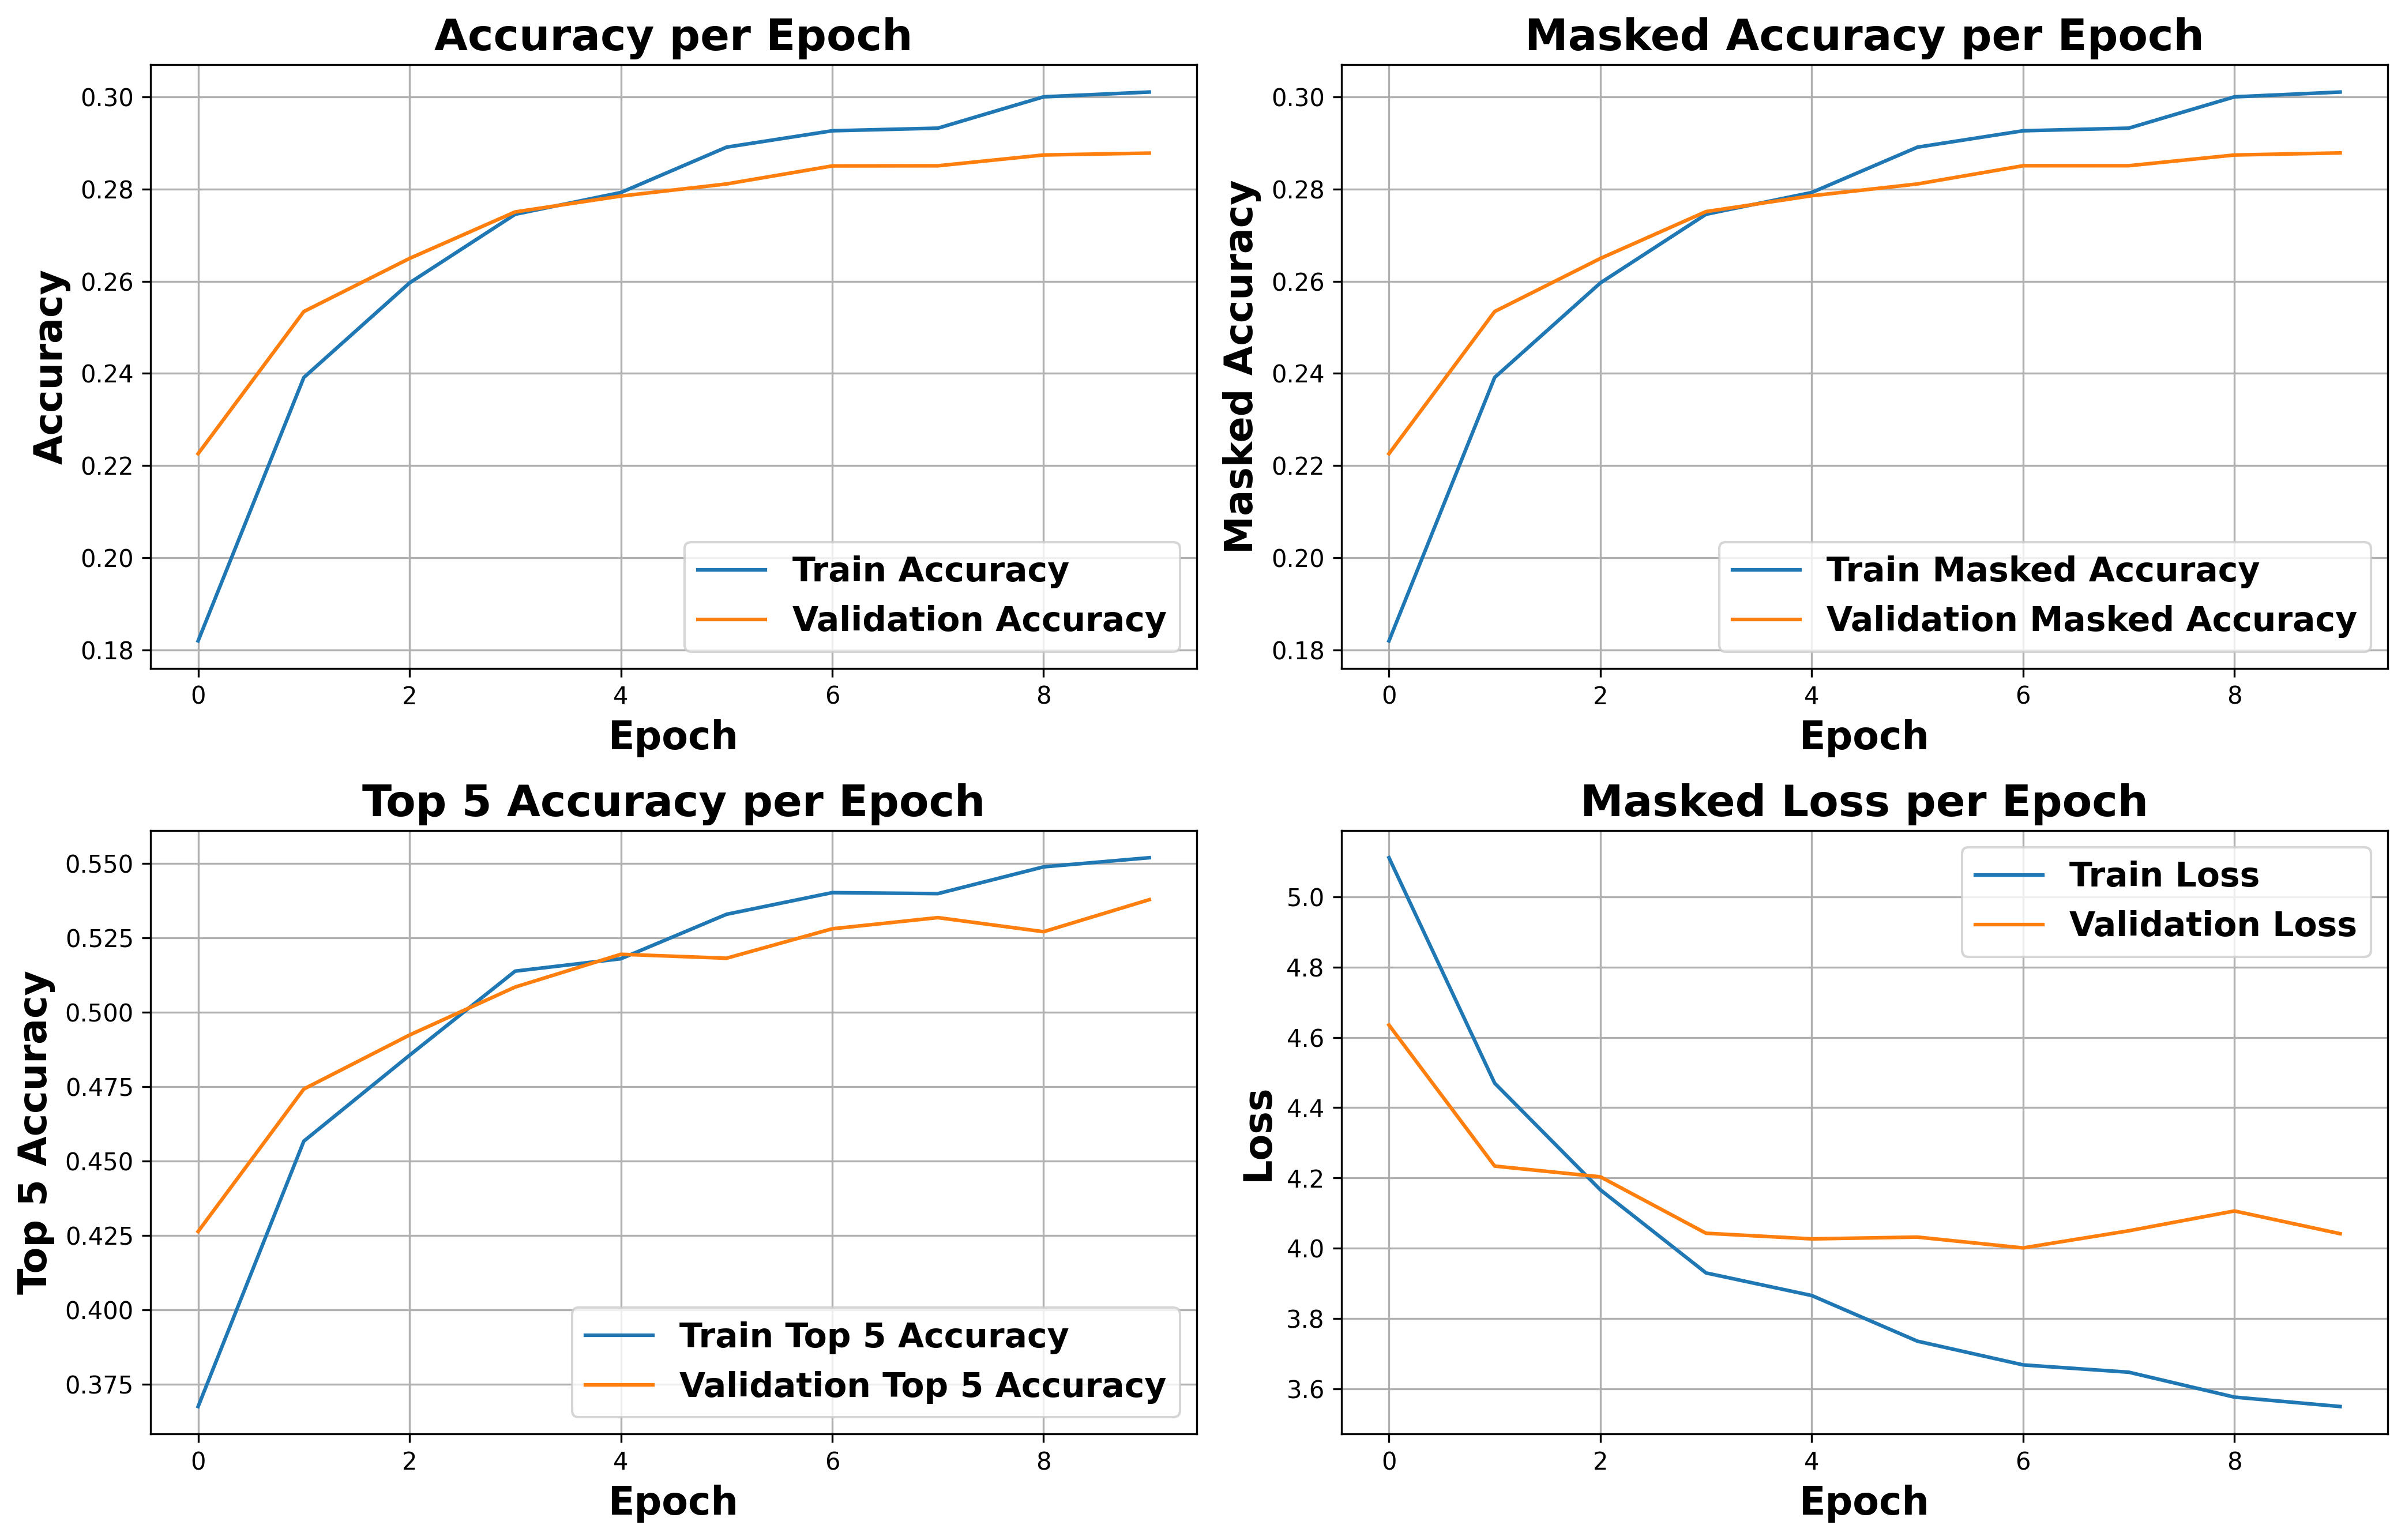

In [19]:
plt.figure(figsize=(14, 9), dpi=300)

plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f'Accuracy per Epoch', size=18, weight='bold')
plt.xlabel('Epoch', size=16, weight='bold')
plt.ylabel('Accuracy', size=16, weight='bold')
plt.legend(prop={'weight': 'bold', 'size': 14})
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(history.history['masked_acc'], label='Train Masked Accuracy')
plt.plot(history.history['val_masked_acc'], label='Validation Masked Accuracy')
plt.title(f'Masked Accuracy per Epoch', size=18, weight='bold')
plt.xlabel('Epoch', size=16, weight='bold')
plt.ylabel('Masked Accuracy', size=16, weight='bold')
plt.legend(prop={'weight': 'bold', 'size': 14})
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(history.history['top_5_accuracy'], label='Train Top 5 Accuracy')
plt.plot(history.history['val_top_5_accuracy'], label='Validation Top 5 Accuracy')
plt.title(f'Top 5 Accuracy per Epoch', size=18, weight='bold')
plt.xlabel('Epoch', size=16, weight='bold')
plt.ylabel('Top 5 Accuracy', size=16, weight='bold')
plt.legend(prop={'weight': 'bold', 'size': 14})
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title(f'Masked Loss per Epoch', size=18, weight='bold')
plt.xlabel('Epoch', size=16, weight='bold')
plt.ylabel('Loss', size=16, weight='bold')
plt.legend(prop={'weight': 'bold', 'size': 14})
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
def extract_features_test(filename, model):
    try:
        image = Image.open(filename)
    except Exception as e:
        print("ERROR: Couldn't open image! Check the image path and extension.")
        return None
    image = image.resize((299, 299))
    image = np.array(image)
    if image.shape[2] == 4:
        image = image[..., :3]
    image = np.expand_dims(image, axis=0)
    image = image / 127.5
    image = image - 1.0
    feature = model.predict(image)
    return feature

def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_caption(model, tokenizer, photo, max_length):
    in_text = 'start'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        pred = model.predict([photo, sequence], verbose=0)
        pred = np.argmax(pred)
        word = word_for_id(pred, tokenizer)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'end':
            break
    return in_text

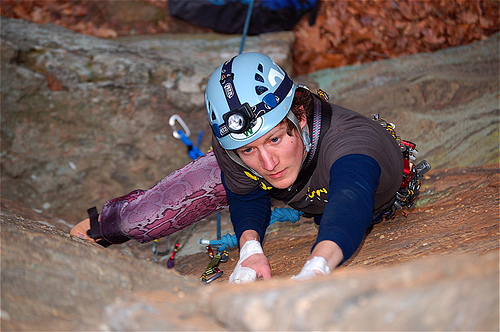

In [21]:
test_img_path = 'Flicker8k_Dataset/111537222_07e56d5a30.jpg'
img = Image.open(test_img_path)
img

In [22]:
xception_model = Xception(include_top=False, pooling="avg")
photo_feature = extract_features_test(test_img_path, xception_model)
generated_caption = generate_caption(model, tokenizer, photo_feature, max_length)
print("Generated Caption for Test Image:")
print(generated_caption.replace('start', '').replace('end', '').strip())

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Generated Caption for Test Image:
man is climbing up rock climbing rock climbing


In [24]:
test_filename = os.path.join(dataset_text, "Flickr_8k.testImages.txt")
test_imgs = load_photos(test_filename)
test_descriptions = load_clean_descriptions("descriptions.txt", test_imgs)
test_features = load_features(test_imgs)

In [26]:
def evaluate_model(model, tokenizer, xception_model, test_features, test_descriptions, max_length):

    smoothing = SmoothingFunction().method1
    rouge_evaluator = Rouge()

    bleu1_scores = []
    bleu2_scores = []
    bleu3_scores = []
    bleu4_scores = []

    rouge_scores_list = []

    for img_id, feature in test_features.items():
        y_pred = generate_caption(model, tokenizer, feature, max_length)
        y_pred_clean = y_pred.replace('start', '').replace('end', '').strip()
        if not y_pred_clean.strip():
            print(f"Skipping ROUGE evaluation for {img_id} due to empty prediction.")
            continue

        pred_tokens = y_pred_clean.split()

        references = test_descriptions[img_id]
        ref_tokens_list = [ref.replace('start', '').replace('end', '').strip().split() for ref in references]

        bleu1 = sentence_bleu(ref_tokens_list, pred_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothing)
        bleu2 = sentence_bleu(ref_tokens_list, pred_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothing)
        bleu3 = sentence_bleu(ref_tokens_list, pred_tokens, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothing)
        bleu4 = sentence_bleu(ref_tokens_list, pred_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothing)

        bleu1_scores.append(bleu1)
        bleu2_scores.append(bleu2)
        bleu3_scores.append(bleu3)
        bleu4_scores.append(bleu4)

        rouge_scores_img = []
        for ref in references:
            ref_clean = ref.replace('start', '').replace('end', '').strip()
            scores = rouge_evaluator.get_scores(y_pred_clean, ref_clean)[0]
            rouge_scores_img.append(scores)

        rouge_avg = {}
        for key in rouge_scores_img[0].keys():
            rouge_avg[key] = np.mean([score[key]['f'] for score in rouge_scores_img])
        rouge_scores_list.append(rouge_avg)

        print(f"Image ID: {img_id}")
        print("Generated Caption:", y_pred_clean)
        print("BLEU-1:", bleu1, "BLEU-2:", bleu2, "BLEU-3:", bleu3, "BLEU-4:", bleu4)
        print("ROUGE-1:", round(rouge_avg.get("rouge-1", 0), 4),
              "ROUGE-2:", round(rouge_avg.get("rouge-2", 0), 4),
              "ROUGE-L:", round(rouge_avg.get("rouge-l", 0), 4))
        print("-" * 50)

    avg_bleu1 = np.mean(bleu1_scores)
    avg_bleu2 = np.mean(bleu2_scores)
    avg_bleu3 = np.mean(bleu3_scores)
    avg_bleu4 = np.mean(bleu4_scores)

    avg_rouge = {}
    for key in rouge_scores_list[0].keys():
        avg_rouge[key] = np.mean([r[key] for r in rouge_scores_list])

    print("\nAverage BLEU-1 Score:", avg_bleu1)
    print("Average BLEU-2 Score:", avg_bleu2)
    print("Average BLEU-3 Score:", avg_bleu3)
    print("Average BLEU-4 Score:", avg_bleu4)
    print("Average ROUGE-1:", round(avg_rouge.get("rouge-1", 0), 4),
          "Average ROUGE-2:", round(avg_rouge.get("rouge-2", 0), 4),
          "Average ROUGE-L:", round(avg_rouge.get("rouge-l", 0), 4))

    results = {
        'BLEU': {
            'BLEU-1': avg_bleu1,
            'BLEU-2': avg_bleu2,
            'BLEU-3': avg_bleu3,
            'BLEU-4': avg_bleu4,
        },
        'ROUGE': {
            'ROUGE-1': round(avg_rouge.get("rouge-1", 0), 4),
            'ROUGE-2': round(avg_rouge.get("rouge-2", 0), 4),
            'ROUGE-L': round(avg_rouge.get("rouge-l", 0), 4)
        }
    }
    return results

In [27]:
results = evaluate_model(model, tokenizer, xception_model, test_features, test_descriptions, max_length)
print("Evaluation Results :")
print(results)

Streaming output truncated to the last 5000 lines.
ROUGE-1: 0.2764 ROUGE-2: 0.0783 ROUGE-L: 0.2764
--------------------------------------------------
Image ID: 311146855_0b65fdb169.jpg
Generated Caption: man in red shirt is standing in front of the water
BLEU-1: 0.36363636363636365 BLEU-2: 0.06030226891555274 BLEU-3: 0.03431428328000597 BLEU-4: 0.026658376817028855
ROUGE-1: 0.172 ROUGE-2: 0.0 ROUGE-L: 0.172
--------------------------------------------------
Image ID: 1258913059_07c613f7ff.jpg
Generated Caption: man in red shirt is standing in front of the the street
BLEU-1: 0.28216057496353797 BLEU-2: 0.20838939520708602 BLEU-3: 0.1543321021076273 BLEU-4: 0.07668068307464099
ROUGE-1: 0.0933 ROUGE-2: 0.0286 ROUGE-L: 0.0933
--------------------------------------------------
Image ID: 241347760_d44c8d3a01.jpg
Generated Caption: man is playing soccer
BLEU-1: 0.14325239843009505 BLEU-2: 0.11696509352786895 BLEU-3: 0.05808600157348 BLEU-4: 0.04867843262263999
ROUGE-1: 0.0857 ROUGE-2: 0.0308 

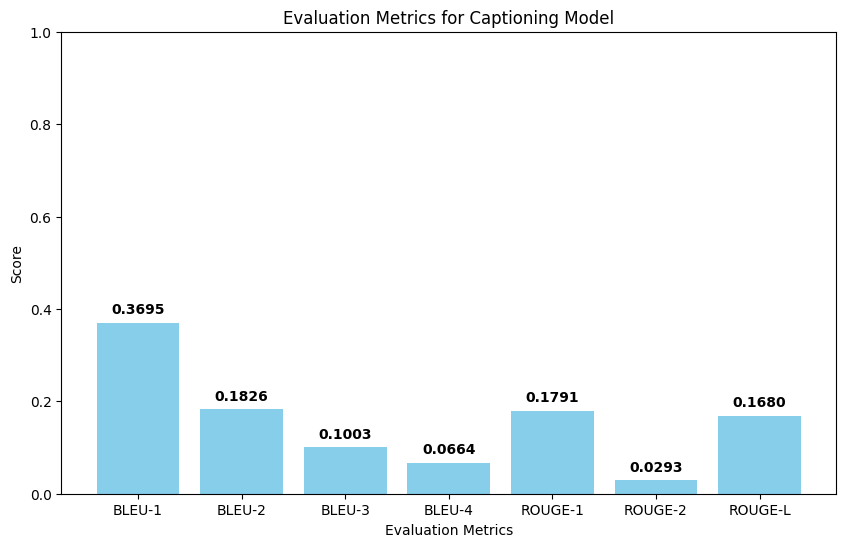

In [28]:
metrics = []
scores = []

for metric, score in results['BLEU'].items():
    metrics.append(metric)
    scores.append(score)

for metric, score in results['ROUGE'].items():
    metrics.append(metric)
    scores.append(score)

plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, scores, color='skyblue')

plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('Evaluation Metrics for Captioning Model')
plt.ylim([0, 1])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.02, f'{height:.4f}', ha='center', fontweight='bold')

plt.show()

In [29]:
def evaluate_cider(model, tokenizer, xception_model, test_features, test_descriptions, max_length):
    cider_scorer = Cider()

    candidate_dict = {}
    reference_dict = {}

    for img_id, feature in test_features.items():
        y_pred = generate_caption(model, tokenizer, feature, max_length)
        y_pred_clean = y_pred.replace('start', '').replace('end', '').strip()

        candidate_dict[img_id] = [y_pred_clean]

        references = [ref.replace('start', '').replace('end', '').strip() for ref in test_descriptions[img_id]]
        reference_dict[img_id] = references

    cid_score, cid_scores = cider_scorer.compute_score(reference_dict, candidate_dict)
    print("CIDEr Score: {:.4f}".format(cid_score))

    return cid_score, cid_scores

cid_score, cid_scores = evaluate_cider(model, tokenizer, xception_model, test_features, test_descriptions, max_length)

print(cid_score)
print(cid_scores)

CIDEr Score: 0.1606
0.16062839325786668
[3.16487667e-03 2.49965432e-01 4.81915118e-02 4.26948056e-02
 2.34433403e-02 8.59284784e-01 6.25604396e-02 1.45117991e-01
 6.01613658e-02 6.07419589e-02 4.65103404e-02 3.65640529e-04
 5.23874730e-04 1.53370901e-01 1.99930165e-01 2.49508101e-01
 1.74061311e-01 2.95420520e-01 7.12362693e-01 7.73708847e-02
 9.01532576e-04 9.46674054e-03 1.62804076e-02 1.76683846e-01
 7.05572550e-02 2.71265548e-01 8.93901502e-02 2.55747458e-02
 5.51773530e-01 2.48079820e-01 4.93905661e-02 6.18058417e-01
 4.87535496e-04 1.93028537e-02 3.72523991e-01 4.35971866e-03
 1.00055541e-01 4.77924200e-01 2.45743248e-04 1.18401797e-01
 1.30291860e-01 6.99080438e-02 2.84213857e-02 2.53057876e-01
 8.33876298e-02 1.97578819e-01 7.01155982e-02 5.42363821e-01
 3.00913966e-04 3.67480365e-01 2.75375559e-02 4.42595953e-01
 7.42839712e-03 1.43735820e-04 1.44161880e-01 6.03567313e-04
 7.14430553e-02 1.20527748e-01 1.71206238e-03 1.43227625e-01
 6.83441710e-01 6.27704977e-02 3.12802542e-01

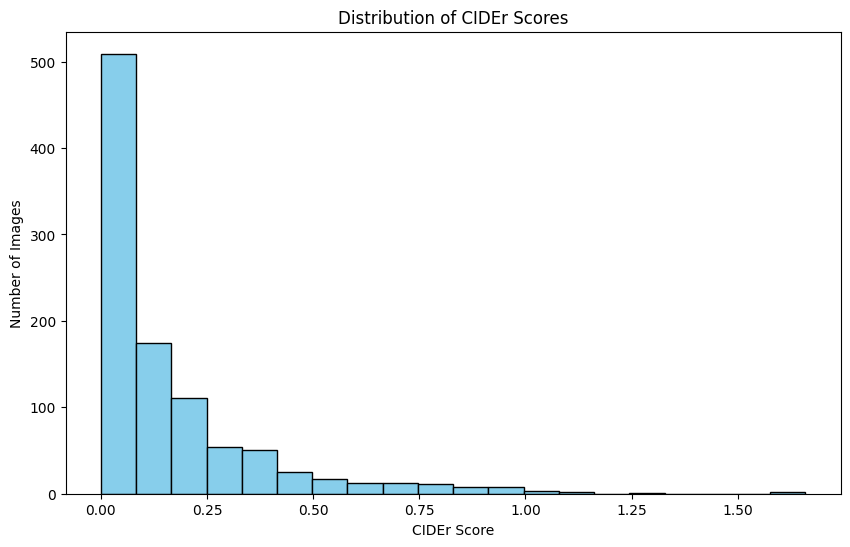

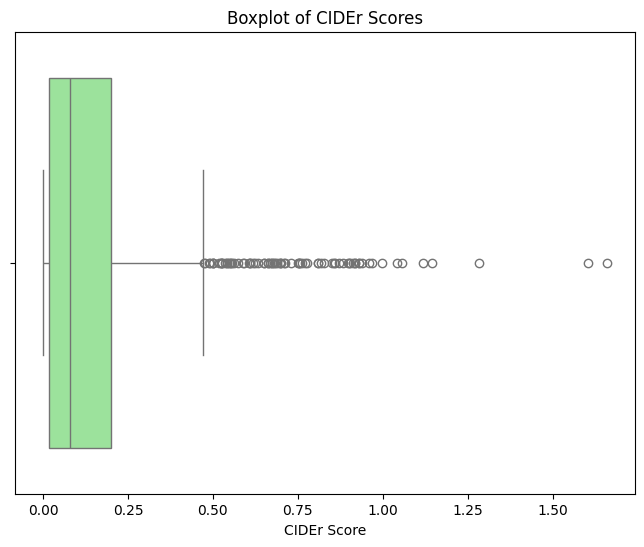

In [30]:
if isinstance(cid_scores, dict):
    scores_list = list(cid_scores.values())
else:
    scores_list = cid_scores

plt.figure(figsize=(10, 6))
plt.hist(scores_list, bins=20, color='skyblue', edgecolor='black')
plt.xlabel("CIDEr Score")
plt.ylabel("Number of Images")
plt.title("Distribution of CIDEr Scores")
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x=scores_list, color='lightgreen')
plt.xlabel("CIDEr Score")
plt.title("Boxplot of CIDEr Scores")
plt.show()

In [31]:
def evaluate_spice(model, tokenizer, test_features, test_descriptions, max_length):
    spice_scorer = Spice()

    candidate_dict = {}
    reference_dict = {}

    for img_id, feature in test_features.items():
        candidate = generate_caption(model, tokenizer, feature, max_length)
        candidate_clean = candidate.replace('start', '').replace('end', '').strip()
        candidate_dict[img_id] = [candidate_clean]

        references = [ref.replace('start', '').replace('end', '').strip() for ref in test_descriptions[img_id]]
        reference_dict[img_id] = references

        print(f"Image ID: {img_id}")
        print("Candidate:", candidate_clean)
        print("References:", references)
        print("-" * 50)

    spice_score, spice_scores = spice_scorer.compute_score(reference_dict, candidate_dict)
    print("Overall SPICE Score: {:.4f}".format(spice_score))
    return spice_score, spice_scores

spice_score, spice_scores = evaluate_spice(model, tokenizer, test_features, test_descriptions, max_length)

Progress: 384.5M / 384.5M (100.0%)
Extracting stanford-corenlp-3.6.0 ...
Done.
Image ID: 3385593926_d3e9c21170.jpg
Candidate: dog running through the grass
References: ['<> the dogs are in the snow in front of fence <>', '<> the dogs play on the snow <>', '<> two brown dogs playfully fight in the snow <>', '<> two brown dogs wrestle in the snow <>', '<> two dogs playing in the snow <>']
--------------------------------------------------
Image ID: 2677656448_6b7e7702af.jpg
Candidate: dog is running through the grass
References: ['<> brown and white dog swimming towards some in the pool <>', '<> dog in swimming pool swims toward sombody we cannot see <>', '<> dog swims in pool near person <>', '<> small dog is paddling through the water in pool <>', '<> the small brown and white dog is in the pool <>']
--------------------------------------------------
Image ID: 311146855_0b65fdb169.jpg
Candidate: man in red shirt is standing in front of the water
References: ['<> man and woman in festiv

In [36]:
print("SPICE Scores:", spice_scores)
print("Number of SPICE Scores:", len(spice_scores))

SPICE Scores: [{'All': {'pr': 0.3333333333333333, 're': 0.06666666666666667, 'f': 0.1111111111111111, 'fn': 28.0, 'numImages': 1.0, 'fp': 4.0, 'tp': 2.0}, 'Relation': {'pr': 0.0, 're': 0.0, 'f': 0.0, 'fn': 7.0, 'numImages': 1.0, 'fp': 2.0, 'tp': 0.0}, 'Cardinality': {'pr': nan, 're': nan, 'f': nan, 'fn': 0.0, 'numImages': 1.0, 'fp': 0.0, 'tp': 0.0}, 'Attribute': {'pr': 0.0, 're': 0.0, 'f': 0.0, 'fn': 11.0, 'numImages': 1.0, 'fp': 1.0, 'tp': 0.0}, 'Size': {'pr': nan, 're': nan, 'f': nan, 'fn': 0.0, 'numImages': 1.0, 'fp': 0.0, 'tp': 0.0}, 'Color': {'pr': 0.0, 're': 0.0, 'f': 0.0, 'fn': 3.0, 'numImages': 1.0, 'fp': 1.0, 'tp': 0.0}, 'Object': {'pr': 0.6666666666666666, 're': 0.16666666666666666, 'f': 0.26666666666666666, 'fn': 10.0, 'numImages': 1.0, 'fp': 1.0, 'tp': 2.0}}, {'All': {'pr': 0.2857142857142857, 're': 0.06451612903225806, 'f': 0.10526315789473685, 'fn': 29.0, 'numImages': 1.0, 'fp': 5.0, 'tp': 2.0}, 'Relation': {'pr': 0.0, 're': 0.0, 'f': 0.0, 'fn': 12.0, 'numImages': 1.0, 'f